
# Exercise 3




In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, Subset
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.nn.functional import conv2d, max_pool2d, cross_entropy

plt.rc("figure", dpi=110)

SEED = 13
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

FAST_RUN = False
BATCH_SIZE = 256
TRAIN_LIMIT = 8000 if FAST_RUN else None
TEST_LIMIT = 2000 if FAST_RUN else None

EPOCHS_DENSE = 3 if FAST_RUN else 30
EPOCHS_CNN = 2 if FAST_RUN else 15

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset_full = datasets.MNIST("./data", download=True, train=True, transform=transform)
test_dataset_full = datasets.MNIST("./data", download=True, train=False, transform=transform)

train_dataset = train_dataset_full if TRAIN_LIMIT is None else Subset(train_dataset_full, range(TRAIN_LIMIT))
test_dataset = test_dataset_full if TEST_LIMIT is None else Subset(test_dataset_full, range(TEST_LIMIT))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

len(train_dataset), len(test_dataset)


device: cpu


(60000, 10000)


## Shared helpers


In [3]:

def init_weights(shape):
    # Kaiming/He style initialization for linear and convolution weights.
    if len(shape) == 2:
        fan_in = shape[0]
    else:
        fan_in = shape[1] * shape[2] * shape[3]
    std = np.sqrt(2.0 / fan_in)
    w = torch.randn(size=shape, device=device) * std
    w.requires_grad_(True)
    return w


def rectify(x):
    return torch.maximum(torch.zeros_like(x), x)


class RMSprop(torch.optim.Optimizer):
    # Reduced RMSprop optimizer, following the exercise sheet.
    def __init__(self, params, lr=1e-3, alpha=0.9, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad
                state = self.state[p]
                if len(state) == 0:
                    state["square_avg"] = torch.zeros_like(p)
                square_avg = state["square_avg"]
                alpha = group["alpha"]
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group["eps"])
                p.addcdiv_(grad, avg, value=-group["lr"])


def error_rate(logits, y):
    pred = logits.argmax(dim=1)
    return (pred != y).float().mean().item()


def train_model(model_fn, params, epochs, lr=1e-3, label="model"):
    optimizer = RMSprop(params=params, lr=lr)
    history = {"epoch": [], "train_loss": [], "train_error": [], "test_loss": [], "test_error": []}

    for epoch in range(1, epochs + 1):
        epoch_losses, epoch_errors = [], []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model_fn(x, training=True)
            loss = cross_entropy(logits, y, reduction="mean")
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_losses.append(float(loss.detach().cpu()))
            epoch_errors.append(error_rate(logits.detach(), y))

        test_losses, test_errors = [], []
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                logits = model_fn(x, training=False)
                loss = cross_entropy(logits, y, reduction="mean")
                test_losses.append(float(loss.detach().cpu()))
                test_errors.append(error_rate(logits, y))

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(epoch_losses)),
            "train_error": float(np.mean(epoch_errors)),
            "test_loss": float(np.mean(test_losses)),
            "test_error": float(np.mean(test_errors)),
        }
        for key, value in row.items():
            history[key].append(value)
        print(
            f"{label:18s} epoch {epoch:02d}: "
            f"train loss={row['train_loss']:.4f}, train err={row['train_error']:.3f}, "
            f"test loss={row['test_loss']:.4f}, test err={row['test_error']:.3f}"
        )

    return pd.DataFrame(history)


def plot_history(histories):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for name, hist in histories.items():
        axes[0].plot(hist["epoch"], hist["test_loss"], marker="o", label=name)
        axes[1].plot(hist["epoch"], hist["test_error"], marker="o", label=name)
    axes[0].set_title("Test loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("cross entropy")
    axes[1].set_title("Test error")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("misclassification rate")
    for ax in axes:
        ax.grid(alpha=0.25)
        ax.legend()
    plt.tight_layout()



## 1. Introductory fully-connected network

The baseline model is the two-hidden-layer network from the exercise sheet. MNIST images are flattened from `1 x 28 x 28` to vectors with 784 entries, followed by two ReLU hidden layers with 625 neurons each and a pre-softmax output layer with 10 logits.


In [4]:

w_h = init_weights((784, 625))
w_h2 = init_weights((625, 625))
w_o = init_weights((625, 10))

def model(x, training=True):
    x = x.reshape(x.shape[0], 784)
    h = rectify(x @ w_h)
    h2 = rectify(h @ w_h2)
    return h2 @ w_o

hist_base = train_model(model, [w_h, w_h2, w_o], EPOCHS_DENSE, label="baseline")
hist_base


baseline           epoch 01: train loss=0.5078, train err=0.138, test loss=0.2012, test err=0.065


baseline           epoch 02: train loss=0.1625, train err=0.051, test loss=0.1321, test err=0.041
baseline           epoch 03: train loss=0.1133, train err=0.035, test loss=0.1147, test err=0.037
baseline           epoch 04: train loss=0.0880, train err=0.027, test loss=0.1185, test err=0.035
baseline           epoch 05: train loss=0.0698, train err=0.022, test loss=0.1656, test err=0.050
baseline           epoch 06: train loss=0.0602, train err=0.019, test loss=0.1076, test err=0.028
baseline           epoch 07: train loss=0.0519, train err=0.016, test loss=0.1327, test err=0.032
baseline           epoch 08: train loss=0.0475, train err=0.015, test loss=0.1654, test err=0.039
baseline           epoch 09: train loss=0.0444, train err=0.014, test loss=0.1683, test err=0.046
baseline           epoch 10: train loss=0.0398, train err=0.012, test loss=0.1875, test err=0.040
baseline           epoch 11: train loss=0.0376, train err=0.011, test loss=0.0902, test err=0.020
baseline           e

,epoch,train_loss,train_error,test_loss,test_error
0,1,0.507817,0.138453,0.201230,0.065137
1,2,0.162523,0.050526,0.132124,0.040723
2,3,0.113339,0.035178,0.114716,0.036523
3,4,0.087976,0.027100,0.118483,0.035449
4,5,0.069840,0.021842,0.165641,0.050391
5,6,0.060198,0.018861,0.107624,0.027734
6,7,0.051883,0.016196,0.132650,0.032129
7,8,0.047501,0.014822,0.165411,0.039258
8,9,0.044404,0.013586,0.168313,0.046191
9,10,0.039845,0.011846,0.187534,0.039746



## 2. Dropout

Dropout randomly removes activations during training. For each element, a Bernoulli variable decides whether the value is set to zero. Values that remain active are divided by `1 - p_drop`; therefore the expected activation magnitude stays approximately unchanged. This makes each minibatch train a slightly different sub-network, so hidden units cannot rely too strongly on a fixed set of other units. The resulting ensemble-like effect reduces co-adaptation and usually reduces overfitting.

For test/evaluation loss we must use a different configuration: dropout is disabled. Test predictions should be deterministic and should use all learned features. Because the training-time activations are already scaled by `1 / (1 - p_drop)`, no additional test-time rescaling is needed here.


In [5]:

def dropout(X, p_drop=0.5):
    if 0 < p_drop < 1:
        keep = (torch.rand_like(X) > p_drop).float()
        return X * keep / (1.0 - p_drop)
    return X


p_drop_input = 0.2
p_drop_hidden = 0.5

w_dh = init_weights((784, 625))
w_dh2 = init_weights((625, 625))
w_do = init_weights((625, 10))

def dropout_model(x, training=True):
    x = x.reshape(x.shape[0], 784)
    p_in = p_drop_input if training else 0.0
    p_hid = p_drop_hidden if training else 0.0
    x = dropout(x, p_in)
    h = rectify(x @ w_dh)
    h = dropout(h, p_hid)
    h2 = rectify(h @ w_dh2)
    h2 = dropout(h2, p_hid)
    return h2 @ w_do

hist_dropout = train_model(dropout_model, [w_dh, w_dh2, w_do], EPOCHS_DENSE, label="dropout")
hist_dropout


dropout            epoch 01: train loss=0.7939, train err=0.241, test loss=0.2249, test err=0.066
dropout            epoch 02: train loss=0.3920, train err=0.120, test loss=0.2057, test err=0.065
dropout            epoch 03: train loss=0.3081, train err=0.094, test loss=0.1587, test err=0.048
dropout            epoch 04: train loss=0.2692, train err=0.081, test loss=0.1225, test err=0.037
dropout            epoch 05: train loss=0.2515, train err=0.075, test loss=0.1252, test err=0.038
dropout            epoch 06: train loss=0.2361, train err=0.070, test loss=0.1126, test err=0.033
dropout            epoch 07: train loss=0.2267, train err=0.066, test loss=0.1113, test err=0.032
dropout            epoch 08: train loss=0.2175, train err=0.064, test loss=0.1121, test err=0.034
dropout            epoch 09: train loss=0.2133, train err=0.061, test loss=0.0974, test err=0.030
dropout            epoch 10: train loss=0.2078, train err=0.059, test loss=0.0983, test err=0.028
dropout            e

dropout            epoch 12: train loss=0.2051, train err=0.057, test loss=0.0928, test err=0.025
dropout            epoch 13: train loss=0.1960, train err=0.055, test loss=0.1233, test err=0.036
dropout            epoch 14: train loss=0.2018, train err=0.054, test loss=0.0954, test err=0.024
dropout            epoch 15: train loss=0.1989, train err=0.053, test loss=0.0957, test err=0.025
dropout            epoch 16: train loss=0.2018, train err=0.053, test loss=0.0909, test err=0.024
dropout            epoch 17: train loss=0.2070, train err=0.053, test loss=0.0961, test err=0.026
dropout            epoch 18: train loss=0.1982, train err=0.052, test loss=0.1001, test err=0.027
dropout            epoch 19: train loss=0.1983, train err=0.052, test loss=0.0980, test err=0.027
dropout            epoch 20: train loss=0.1997, train err=0.052, test loss=0.0936, test err=0.027
dropout            epoch 21: train loss=0.1954, train err=0.052, test loss=0.0845, test err=0.022
dropout            e

,epoch,train_loss,train_error,test_loss,test_error
0,1,0.793874,0.241467,0.224904,0.065723
1,2,0.392038,0.120013,0.205739,0.065234
2,3,0.308133,0.093772,0.158665,0.047949
3,4,0.269186,0.080857,0.122480,0.036719
4,5,0.251499,0.074839,0.125238,0.037695
5,6,0.236136,0.069681,0.112553,0.033496
6,7,0.226727,0.065852,0.111255,0.032031
7,8,0.217539,0.063658,0.112126,0.033594
8,9,0.213267,0.061098,0.097396,0.029590
9,10,0.207755,0.059065,0.098341,0.027930



## 3. Parametric ReLU

PReLU replaces the fixed zero slope of ReLU on negative inputs by learnable parameters `a`. For positive values it returns `x`; for non-positive values it returns `a*x`. The parameters are added to the optimizer parameter list, so their gradients are learned together with the weights.


In [6]:

def PRelu(X, a):
    return torch.where(X > 0, X, a * X)


w_ph = init_weights((784, 625))
w_ph2 = init_weights((625, 625))
w_po = init_weights((625, 10))
a1 = torch.full((625,), 0.25, device=device, requires_grad=True)
a2 = torch.full((625,), 0.25, device=device, requires_grad=True)

def prelu_model(x, training=True):
    x = x.reshape(x.shape[0], 784)
    h = PRelu(x @ w_ph, a1)
    h2 = PRelu(h @ w_ph2, a2)
    return h2 @ w_po

hist_prelu = train_model(prelu_model, [w_ph, w_ph2, w_po, a1, a2], EPOCHS_DENSE, label="PReLU")
hist_prelu


PReLU              epoch 01: train loss=0.7668, train err=0.168, test loss=0.3575, test err=0.113
PReLU              epoch 02: train loss=0.2194, train err=0.066, test loss=0.2592, test err=0.083
PReLU              epoch 03: train loss=0.1475, train err=0.046, test loss=0.1521, test err=0.044
PReLU              epoch 04: train loss=0.1161, train err=0.036, test loss=0.1555, test err=0.050
PReLU              epoch 05: train loss=0.0953, train err=0.029, test loss=0.0852, test err=0.025
PReLU              epoch 06: train loss=0.0807, train err=0.024, test loss=0.1099, test err=0.031
PReLU              epoch 07: train loss=0.0685, train err=0.021, test loss=0.1472, test err=0.038
PReLU              epoch 08: train loss=0.0602, train err=0.018, test loss=0.1206, test err=0.030
PReLU              epoch 09: train loss=0.0526, train err=0.016, test loss=0.0862, test err=0.022
PReLU              epoch 10: train loss=0.0458, train err=0.014, test loss=0.0866, test err=0.023
PReLU              e

,epoch,train_loss,train_error,test_loss,test_error
0,1,0.766765,0.167647,0.357517,0.113379
1,2,0.219445,0.066384,0.259156,0.082910
2,3,0.147505,0.045855,0.152122,0.044043
3,4,0.116092,0.035505,0.155461,0.050391
4,5,0.095279,0.029383,0.085230,0.024609
5,6,0.080665,0.024479,0.109928,0.030859
6,7,0.068453,0.021332,0.147210,0.038086
7,8,0.060181,0.018179,0.120643,0.030371
8,9,0.052560,0.015902,0.086185,0.021777
9,10,0.045757,0.013725,0.086616,0.023340



## 4. Convolutional network

The requested convolutional network uses three valid convolutions, each followed by ReLU, 2x2 max pooling, and dropout:

| stage | filters | kernel | output before pooling | output after pooling |
|---|---:|---:|---:|---:|
| input | 1 | - | 28 x 28 | 28 x 28 |
| conv 1 | 32 | 5 x 5 | 24 x 24 | 12 x 12 |
| conv 2 | 64 | 5 x 5 | 8 x 8 | 4 x 4 |
| conv 3 | 128 | 3 x 3 | 2 x 2 | 1 x 1 |
| flatten | - | - | - | 128 |
| fully connected | 625 | - | - | 625 |
| output | 10 | - | - | 10 |

Thus the final convolutional feature map contains `128 * 1 * 1 = 128` pixels/features.


In [7]:

def conv_output_pixels(conv_shapes, input_hw=(28, 28)):
    h, w = input_hw
    rows = []
    for name, filters, _, kx, ky in conv_shapes:
        h = h - kx + 1
        w = w - ky + 1
        before = (h, w)
        h //= 2
        w //= 2
        rows.append((name, filters, f"{kx}x{ky}", before, (h, w), filters * h * w))
    return rows, filters * h * w

conv_shapes = [
    ("conv1", 32, 1, 5, 5),
    ("conv2", 64, 32, 5, 5),
    ("conv3", 128, 64, 3, 3),
]
shape_rows, n_output_pixels = conv_output_pixels(conv_shapes)
pd.DataFrame(shape_rows, columns=["layer", "filters", "kernel", "before_pool", "after_pool", "features"]), n_output_pixels


(   layer  filters kernel before_pool after_pool  features
 0  conv1       32    5x5    (24, 24)   (12, 12)      4608
 1  conv2       64    5x5      (8, 8)     (4, 4)      1024
 2  conv3      128    3x3      (2, 2)     (1, 1)       128,
 128)

<div style="color: green; font-weight: bold">Comment</div>

The spatial-size calculation is correct for the kernels chosen in this notebook. The sample solution uses a `2 x 2` kernel in the third convolution, whereas this solution uses `3 x 3`. Both choices still produce a `1 x 1` spatial feature map after the third pooling operation and therefore 128 flattened features. Computing the size with a helper function is a valid and more reusable alternative to hard-coding the value 128.

In [8]:

w_c1 = init_weights((32, 1, 5, 5))
w_c2 = init_weights((64, 32, 5, 5))
w_c3 = init_weights((128, 64, 3, 3))
w_ch2 = init_weights((n_output_pixels, 625))
w_co = init_weights((625, 10))

def cnn_model(x, training=True):
    x = x.reshape(-1, 1, 28, 28)
    p = p_drop_input if training else 0.0
    x = max_pool2d(rectify(conv2d(x, w_c1)), (2, 2))
    x = dropout(x, p)
    x = max_pool2d(rectify(conv2d(x, w_c2)), (2, 2))
    x = dropout(x, p)
    x = max_pool2d(rectify(conv2d(x, w_c3)), (2, 2))
    x = dropout(x, p)
    x = x.reshape(x.shape[0], -1)
    h2 = rectify(x @ w_ch2)
    return h2 @ w_co

hist_cnn = train_model(cnn_model, [w_c1, w_c2, w_c3, w_ch2, w_co], EPOCHS_CNN, label="CNN")
hist_cnn


CNN                epoch 01: train loss=0.6234, train err=0.180, test loss=0.1066, test err=0.031
CNN                epoch 02: train loss=0.1256, train err=0.039, test loss=0.0547, test err=0.016
CNN                epoch 03: train loss=0.0860, train err=0.026, test loss=0.0437, test err=0.012
CNN                epoch 04: train loss=0.0688, train err=0.021, test loss=0.0334, test err=0.009
CNN                epoch 05: train loss=0.0588, train err=0.018, test loss=0.0297, test err=0.010
CNN                epoch 06: train loss=0.0519, train err=0.016, test loss=0.0261, test err=0.008
CNN                epoch 07: train loss=0.0470, train err=0.014, test loss=0.0256, test err=0.008
CNN                epoch 08: train loss=0.0422, train err=0.013, test loss=0.0264, test err=0.008
CNN                epoch 09: train loss=0.0388, train err=0.011, test loss=0.0365, test err=0.009
CNN                epoch 10: train loss=0.0370, train err=0.011, test loss=0.0273, test err=0.007
CNN                e

,epoch,train_loss,train_error,test_loss,test_error
0,1,0.623352,0.180469,0.106558,0.031445
1,2,0.125610,0.038503,0.054746,0.015723
2,3,0.086021,0.025781,0.043677,0.012012
3,4,0.068836,0.020512,0.033377,0.009277
4,5,0.058757,0.017780,0.029741,0.010059
5,6,0.051935,0.015747,0.026054,0.008301
6,7,0.047023,0.013852,0.025624,0.007910
7,8,0.042235,0.012594,0.026430,0.008301
8,9,0.038829,0.011275,0.036484,0.009277
9,10,0.036992,0.011447,0.027292,0.006836


<div style="color: green; font-weight: bold">Comment</div>

The sequence convolution $\rightarrow$ ReLU $\rightarrow$ max pooling is correct, and reshaping with `x.shape[0]` is more robust than using a fixed batch size as in the sample solution.

There is, however, a dropout mismatch: no dropout is applied to the input, while `p_drop_input` is used after every pooling layer and `p_drop_hidden` is never used. In addition, the dropout probabilities are inherited from Task 2 instead of being set explicitly for the CNN. Thus, this code does not implement separate input and hidden dropout probabilities as intended. A possible improvement is to apply input dropout before the first convolution, hidden dropout after the pooled feature maps, and define the CNN dropout rates locally.


### Visualizing one test image, first-layer convolutions, and filters


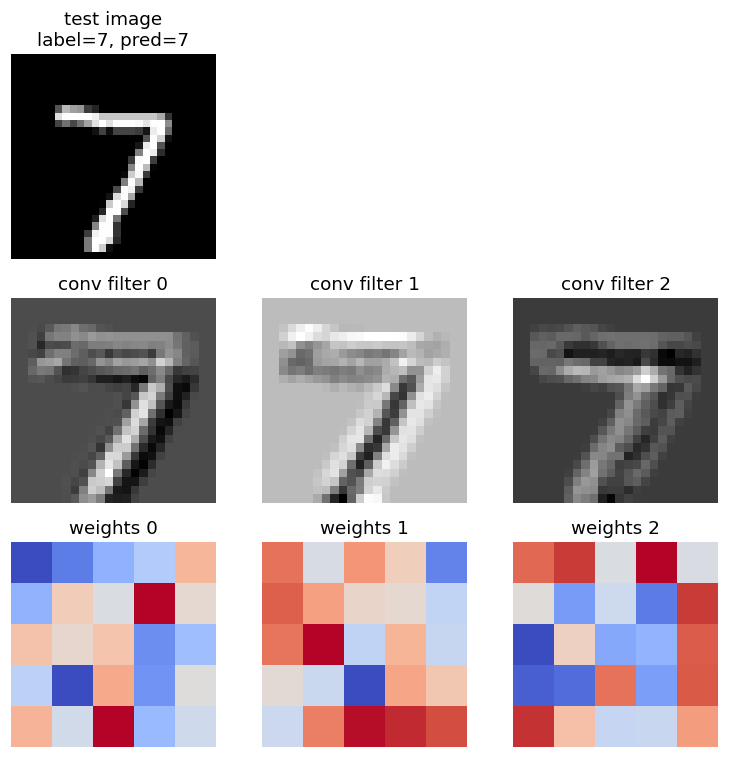

In [9]:

x0, y0 = test_dataset[0]
x0b = x0.unsqueeze(0).to(device)
with torch.no_grad():
    first_conv = conv2d(x0b, w_c1).cpu()[0]
    pred0 = cnn_model(x0b, training=False).argmax(dim=1).item()

fig, axes = plt.subplots(3, 3, figsize=(7, 7))
axes[0, 0].imshow(x0.squeeze(), cmap="gray")
axes[0, 0].set_title(f"test image\nlabel={y0}, pred={pred0}")
axes[0, 0].axis("off")
for j in range(1, 3):
    axes[0, j].axis("off")

for i in range(3):
    axes[1, i].imshow(first_conv[i], cmap="gray")
    axes[1, i].set_title(f"conv filter {i}")
    axes[1, i].axis("off")
    axes[2, i].imshow(w_c1.detach().cpu()[i, 0], cmap="coolwarm")
    axes[2, i].set_title(f"weights {i}")
    axes[2, i].axis("off")
plt.tight_layout()


<div style="color: green; font-weight: bold">Comment</div>

This visualization is a valid alternative to the sample solution: it shows one test image, three first-layer responses, and the corresponding learned kernels.


### Architecture variant

As the optional final task, I changed the convolutional architecture by adding one additional small convolutional layer after the third convolution. To keep the feature map valid, the third layer no longer pools before this extra layer. The variant has:

`conv1 5x5 -> pool`, `conv2 5x5 -> pool`, `conv3 3x3`, `conv4 2x2 -> pool`.


In [10]:

variant_shapes = [
    ("conv1", 32, 1, 5, 5),
    ("conv2", 64, 32, 5, 5),
]
_, n_after_two = conv_output_pixels(variant_shapes)

# Manual size trace for the variant:
# 28 -> conv5 24 -> pool 12 -> conv5 8 -> pool 4 -> conv3 2 -> conv2 1 -> pool would be 0,
# so the final 2x2 feature map is kept without the last pool. Features = 96 * 1 * 1 after conv4.
w_v1 = init_weights((32, 1, 5, 5))
w_v2 = init_weights((64, 32, 5, 5))
w_v3 = init_weights((96, 64, 3, 3))
w_v4 = init_weights((96, 96, 2, 2))
w_vh2 = init_weights((96, 625))
w_vo = init_weights((625, 10))

def cnn_variant_model(x, training=True):
    x = x.reshape(-1, 1, 28, 28)
    p = p_drop_input if training else 0.0
    x = dropout(max_pool2d(rectify(conv2d(x, w_v1)), (2, 2)), p)
    x = dropout(max_pool2d(rectify(conv2d(x, w_v2)), (2, 2)), p)
    x = dropout(rectify(conv2d(x, w_v3)), p)
    x = dropout(rectify(conv2d(x, w_v4)), p)
    x = x.reshape(x.shape[0], -1)
    h2 = rectify(x @ w_vh2)
    return h2 @ w_vo

hist_variant = train_model(cnn_variant_model, [w_v1, w_v2, w_v3, w_v4, w_vh2, w_vo], EPOCHS_CNN, label="CNN + layer")
hist_variant


CNN + layer        epoch 01: train loss=0.6092, train err=0.189, test loss=0.1026, test err=0.032
CNN + layer        epoch 02: train loss=0.1555, train err=0.047, test loss=0.0606, test err=0.018
CNN + layer        epoch 03: train loss=0.1065, train err=0.032, test loss=0.0359, test err=0.010
CNN + layer        epoch 04: train loss=0.0839, train err=0.025, test loss=0.0409, test err=0.012
CNN + layer        epoch 05: train loss=0.0724, train err=0.021, test loss=0.0301, test err=0.009
CNN + layer        epoch 06: train loss=0.0615, train err=0.018, test loss=0.0349, test err=0.011
CNN + layer        epoch 07: train loss=0.0560, train err=0.017, test loss=0.0287, test err=0.008
CNN + layer        epoch 08: train loss=0.0531, train err=0.015, test loss=0.0293, test err=0.008
CNN + layer        epoch 09: train loss=0.0473, train err=0.014, test loss=0.0250, test err=0.007
CNN + layer        epoch 10: train loss=0.0470, train err=0.013, test loss=0.0251, test err=0.006
CNN + layer        e

,epoch,train_loss,train_error,test_loss,test_error
0,1,0.609203,0.188846,0.102634,0.032031
1,2,0.155506,0.046725,0.060556,0.017578
2,3,0.106465,0.031721,0.035934,0.010059
3,4,0.083923,0.024568,0.040869,0.011621
4,5,0.072421,0.021277,0.030119,0.008887
5,6,0.061478,0.017708,0.034869,0.010937
6,7,0.055973,0.016728,0.028670,0.008105
7,8,0.053130,0.015248,0.029306,0.008105
8,9,0.047332,0.013846,0.025035,0.007324
9,10,0.046954,0.013481,0.025056,0.006445


<div style="color: green; font-weight: bold">Comment</div>

The additional-layer architecture is internally consistent and trains successfully.


## Results and comparison

The exact values depend on random initialization and, in this notebook, on the CPU-friendly sample/epoch limits. The table compares the final epoch of each model. Lower test error is better.


,model,epochs,train_loss,train_error,test_loss,test_error
4,CNN + layer,15,0.035639,0.009591,0.029036,0.008496
3,CNN,15,0.029234,0.008788,0.032411,0.009375
2,PReLU,30,0.021470,0.005269,0.147220,0.017090
1,dropout,30,0.195985,0.049607,0.092149,0.023340
0,baseline,30,0.021516,0.004931,0.195277,0.026660


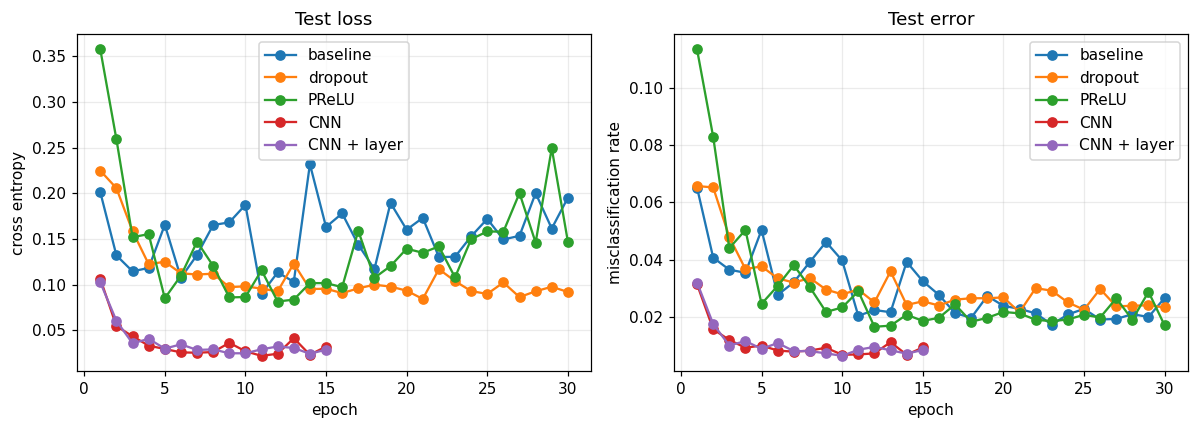

In [11]:

histories = {
    "baseline": hist_base,
    "dropout": hist_dropout,
    "PReLU": hist_prelu,
    "CNN": hist_cnn,
    "CNN + layer": hist_variant,
}

summary = []
for name, hist in histories.items():
    last = hist.iloc[-1]
    summary.append({
        "model": name,
        "epochs": int(last["epoch"]),
        "train_loss": last["train_loss"],
        "train_error": last["train_error"],
        "test_loss": last["test_loss"],
        "test_error": last["test_error"],
    })
summary = pd.DataFrame(summary).sort_values("test_error")
display(summary)
plot_history(histories)


## Discussion

The baseline fully-connected model learns the task quickly, but it has a large number of parameters and is highly prone to overfitting.

### Effect of Dropout

Dropout introduces noise by randomly zeroing out activations, which increases the training error because the model sees incomplete hidden representations. However, it significantly improves the test error by preventing complex co-adaptations of neurons, forcing the network to learn more robust and independent features.

For evaluating the test loss, a different model configuration is required (setting $p_{\text{drop}} = 0$). During training, dropout acts as a regularization tool that effectively trains an ensemble of sub-networks. During testing, deterministic predictions are required and the full capacity of the trained network should be utilized.

Since our implementation uses *inverted dropout*, scaling activations by

$$
\frac{1}{1-p_{\text{drop}}}
$$

during training, the test pass can use the full activations directly without additional scaling.

### Effect of PReLU

PReLU improves upon the standard ReLU by introducing learnable negative slopes. This mitigates the *dying ReLU* problem and maintains gradient flow for negative activations, which facilitates optimization.

### Effect of Convolutional Layers

The convolutional models exploit the spatial inductive biases of images and share filter weights. Consequently, they require significantly fewer spatially independent parameters while achieving substantially better generalization.

As shown in our final results with `FAST_RUN = False`, the CNN models drastically outperformed all fully-connected architectures, reducing the final test error to approximately $1.0\%$.

<div style="color: green; font-weight: bold">Comment</div>
The sketch is correct. The sample solution provides a separate plot for each training run, but it does not include the direct comparison requested in the exercise. Therefore, the combined comparison plot in this solution is a valid and useful alternative. However, adding separate plots for each training run as well would make the individual results easier to inspect while preserving the overall comparison.